In [1]:
import sys

sys.path.append("..")

import matplotlib.pyplot as plt
import polars as pl
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

from aktipp.eval import ak_score, mean_ak_score
from aktipp.model import DummyClassifier, GoalsMapper

In [2]:
%matplotlib inline

In [3]:
df = pl.read_parquet(
    "/home/fabian/Project-Data/AK-Tippspiel/openligadb/openligadb_result_class_dataset.parquet"
)
df.head()

match_id,league_id,match_day,team_id_1,team_name_1,team_id_2,team_name_2,goals_team_1,goals_team_2,goals_diff,result_class,home_team,games_1,rank_1,games_2,rank_2,rank_diff,wins_last_3_games_1,wins_last_5_games_1,wins_avg_1,draws_last_3_games_1,draws_last_5_games_1,draws_avg_1,losses_last_3_games_1,losses_last_5_games_1,losses_avg_1,points_last_3_games_1,points_last_5_games_1,points_avg_1,goals_scored_last_3_games_1,goals_scored_last_5_games_1,goals_scored_avg_1,goals_conceded_last_3_games_1,goals_conceded_last_5_games_1,goals_conceded_avg_1,goals_diff_last_3_games_1,goals_diff_last_5_games_1,goals_diff_avg_1,wins_last_3_games_2,wins_last_5_games_2,wins_avg_2,draws_last_3_games_2,draws_last_5_games_2,draws_avg_2,losses_last_3_games_2,losses_last_5_games_2,losses_avg_2,points_last_3_games_2,points_last_5_games_2,points_avg_2,goals_scored_last_3_games_2,goals_scored_last_5_games_2,goals_scored_avg_2,goals_conceded_last_3_games_2,goals_conceded_last_5_games_2,goals_conceded_avg_2,goals_diff_last_3_games_2,goals_diff_last_5_games_2,goals_diff_avg_2
i64,i64,i64,i64,str,i64,str,i64,i64,i64,i32,i32,i32,i64,i32,i64,i64,i32,i32,f64,i32,i32,f64,i32,i32,f64,i32,i32,f64,i64,i64,f64,i64,i64,f64,i64,i64,f64,i32,i32,f64,i32,i32,f64,i32,i32,f64,i32,i32,f64,i64,i64,f64,i64,i64,f64,i64,i64,f64
4574,49,1,40,"""FC Bayern München""",91,"""Eintracht Frankfurt""",3,1,2,1,1,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
4575,49,1,131,"""VfL Wolfsburg""",129,"""VfL Bochum""",3,2,1,1,1,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
4576,49,1,76,"""1. FC Kaiserslautern""",125,"""TSV 1860 München""",0,1,-1,-1,1,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
4577,49,1,54,"""Hertha BSC""",134,"""Werder Bremen""",0,3,-3,-1,1,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
4581,49,1,87,"""Borussia Mönchengladbach""",65,"""1. FC Köln""",1,0,1,1,1,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null


In [4]:
ids = [
    "match_id",
    "league_id",
    "match_day",
    "team_id_1",
    "team_name_1",
    "team_id_2",
    "team_name_2",
]

# target = 'result_class'
target = ["result_class"]
goals = ["goals_team_1", "goals_team_2"]

train_cols = [
    "home_team",
    "games_1",
    "rank_1",
    "games_2",
    "rank_2",
    "rank_diff",
    "wins_last_3_games_1",
    "wins_last_5_games_1",
    "wins_avg_1",
    "draws_last_3_games_1",
    "draws_last_5_games_1",
    "draws_avg_1",
    "losses_last_3_games_1",
    "losses_last_5_games_1",
    "losses_avg_1",
    "points_last_3_games_1",
    "points_last_5_games_1",
    "points_avg_1",
    "goals_scored_last_3_games_1",
    "goals_scored_last_5_games_1",
    "goals_scored_avg_1",
    "goals_conceded_last_3_games_1",
    "goals_conceded_last_5_games_1",
    "goals_conceded_avg_1",
    "goals_diff_last_3_games_1",
    "goals_diff_last_5_games_1",
    "goals_diff_avg_1",
    "wins_last_3_games_2",
    "wins_last_5_games_2",
    "wins_avg_2",
    "draws_last_3_games_2",
    "draws_last_5_games_2",
    "draws_avg_2",
    "losses_last_3_games_2",
    "losses_last_5_games_2",
    "losses_avg_2",
    "points_last_3_games_2",
    "points_last_5_games_2",
    "points_avg_2",
    "goals_scored_last_3_games_2",
    "goals_scored_last_5_games_2",
    "goals_scored_avg_2",
    "goals_conceded_last_3_games_2",
    "goals_conceded_last_5_games_2",
    "goals_conceded_avg_2",
    "goals_diff_last_3_games_2",
    "goals_diff_last_5_games_2",
    "goals_diff_avg_2",
]

In [5]:
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

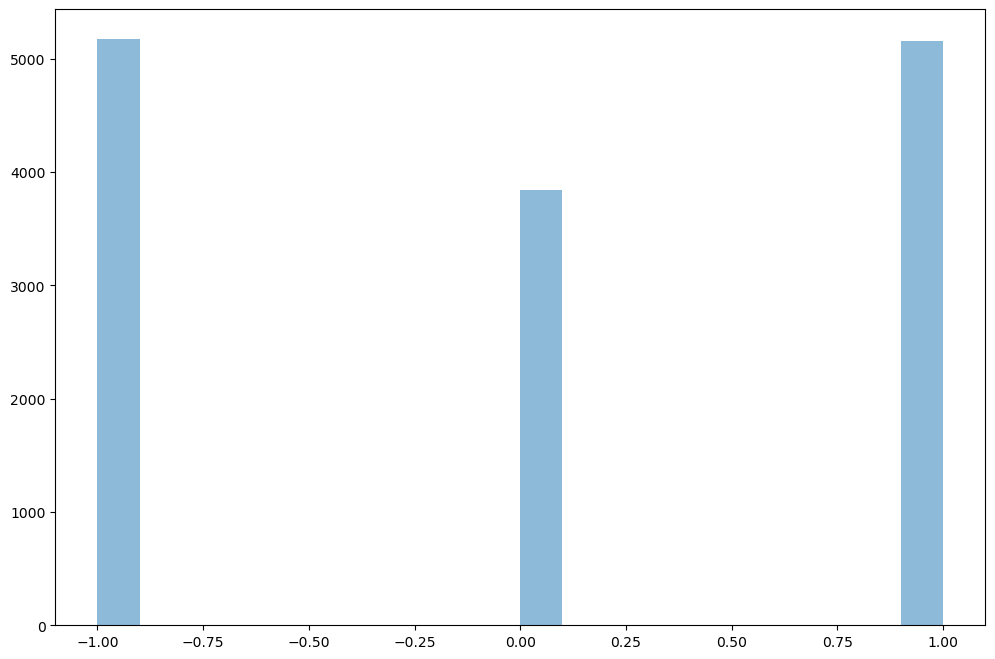

In [6]:
fig, ax = plt.subplots(figsize=(12, 8))


for t in target:
    ax.hist(df_train[t], label=t, alpha=0.5, bins=20)

In [7]:
dummy = GoalsMapper(DummyClassifier(), suffix="_dummy")
dummy.fit(df_train[train_cols], df_train[target], df_train[goals])
dummy.predict(df_train[train_cols])

result_class_pred_dummy,exact_result_pred_dummy,goals_team_1_pred_dummy,goals_team_2_pred_dummy
i32,str,i64,i64
-1,"""1:2""",1,2
-1,"""1:2""",1,2
-1,"""1:2""",1,2
1,"""1:0""",1,0
-1,"""1:2""",1,2
…,…,…,…
-1,"""1:2""",1,2
-1,"""1:2""",1,2
1,"""1:0""",1,0


In [8]:
df_train = df_train.with_columns(dummy.predict(df_train[train_cols]))

In [9]:
df_test = df_test.with_columns(dummy.predict(df_test[train_cols]))

In [10]:
print(
    classification_report(
        df_train[target], df_train["result_class_pred_dummy"], zero_division=0
    )
)

              precision    recall  f1-score   support

          -1       0.44      0.60      0.51      5177
           0       0.00      0.00      0.00      3838
           1       0.44      0.60      0.51      5158

    accuracy                           0.44     14173
   macro avg       0.29      0.40      0.34     14173
weighted avg       0.32      0.44      0.37     14173



In [11]:
print(
    classification_report(
        df_test[target], df_test["result_class_pred_dummy"], zero_division=0
    )
)

              precision    recall  f1-score   support

          -1       0.44      0.61      0.51      1298
           0       0.00      0.00      0.00       919
           1       0.46      0.60      0.52      1327

    accuracy                           0.45      3544
   macro avg       0.30      0.40      0.34      3544
weighted avg       0.33      0.45      0.38      3544



In [12]:
mean_ak_score(
    df_train[goals], df_train[["goals_team_1_pred_dummy", "goals_team_2_pred_dummy"]]
)

np.float64(0.9662739010795174)

In [13]:
mean_ak_score(
    df_test[goals], df_test[["goals_team_1_pred_dummy", "goals_team_2_pred_dummy"]]
)

np.float64(0.9740406320541761)

In [14]:
mean_ak_score(
    df_train[goals],
    df_train.select(
        pl.when(pl.col("home_team") == 1)
        .then(2)
        .otherwise(1)
        .alias("goals_team_1_pred_dummy"),
        pl.when(pl.col("home_team") == 1)
        .then(1)
        .otherwise(2)
        .alias("goals_team_2_pred_dummy"),
    ),
)

np.float64(0.9638749735412404)

In [15]:
mean_ak_score(
    df_test[goals],
    df_test.select(
        pl.when(pl.col("home_team") == 1)
        .then(2)
        .otherwise(1)
        .alias("goals_team_1_pred_dummy"),
        pl.when(pl.col("home_team") == 1)
        .then(1)
        .otherwise(2)
        .alias("goals_team_2_pred_dummy"),
    ),
)

np.float64(0.9830699774266366)

In [16]:
df_2425 = df.filter(pl.col("league_id") == 4741)
df_2425 = df_2425.with_columns(dummy.predict(df_2425[train_cols]))

In [17]:
mean_ak_score(
    df_2425[goals], df_2425[["goals_team_1_pred_dummy", "goals_team_2_pred_dummy"]]
)

np.float64(0.9722222222222222)

In [18]:
ak_score(
    df_2425[goals],
    df_2425.select(
        pl.when(pl.col("home_team") == 1)
        .then(2)
        .otherwise(1)
        .alias("goals_team_1_pred_dummy"),
        pl.when(pl.col("home_team") == 1)
        .then(1)
        .otherwise(2)
        .alias("goals_team_2_pred_dummy"),
    ),
)

array([2, 2, 0, 0, 2, 0, 0, 2, 0, 0, 2, 2, 2, 0, 3, 0, 0, 0, 3, 2, 0, 2,
       2, 0, 0, 0, 0, 3, 3, 2, 2, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 2, 0,
       2, 0, 0, 2, 2, 2, 2, 2, 0, 2, 0, 2, 0, 0, 0, 2, 2, 0, 0, 0, 0, 0,
       0, 2, 0, 0, 0, 2, 2, 0, 2, 0, 0, 0, 3, 0, 0, 3, 0, 0, 0, 2, 0, 2,
       2, 3, 2, 2, 0, 3, 0, 3, 2, 0, 0, 0, 0, 2, 2, 2, 0, 2, 0, 2])

In [19]:
ak_score(
    df_2425[goals],
    df_2425.select(
        pl.when(pl.col("home_team") == 1)
        .then(2)
        .otherwise(1)
        .alias("goals_team_1_pred_dummy"),
        pl.when(pl.col("home_team") == 1)
        .then(1)
        .otherwise(2)
        .alias("goals_team_2_pred_dummy"),
    ),
).sum()

np.int64(106)

In [20]:
df_2425.with_columns(
    ak_score=ak_score(
        df_2425[goals],
        df_2425.select(
            pl.when(pl.col("home_team") == 1)
            .then(2)
            .otherwise(1)
            .alias("goals_team_1_pred_dummy"),
            pl.when(pl.col("home_team") == 1)
            .then(1)
            .otherwise(2)
            .alias("goals_team_2_pred_dummy"),
        ),
    )
).group_by("match_day").agg(pl.col("ak_score").sum()).sort("match_day")

match_day,ak_score
i64,i64
1,8
2,8
3,7
4,9
5,6
…,…
8,8
9,11
10,5


In [21]:
df_2425.with_columns(
    ak_score=ak_score(
        df_2425[goals],
        df_2425.select(
            pl.when(pl.col("home_team") == 1)
            .then(2)
            .otherwise(1)
            .alias("goals_team_1_pred_dummy"),
            pl.when(pl.col("home_team") == 1)
            .then(1)
            .otherwise(2)
            .alias("goals_team_2_pred_dummy"),
        ),
    )
)

match_id,league_id,match_day,team_id_1,team_name_1,team_id_2,team_name_2,goals_team_1,goals_team_2,goals_diff,result_class,home_team,games_1,rank_1,games_2,rank_2,rank_diff,wins_last_3_games_1,wins_last_5_games_1,wins_avg_1,draws_last_3_games_1,draws_last_5_games_1,draws_avg_1,losses_last_3_games_1,losses_last_5_games_1,losses_avg_1,points_last_3_games_1,points_last_5_games_1,points_avg_1,goals_scored_last_3_games_1,goals_scored_last_5_games_1,goals_scored_avg_1,goals_conceded_last_3_games_1,goals_conceded_last_5_games_1,goals_conceded_avg_1,goals_diff_last_3_games_1,goals_diff_last_5_games_1,goals_diff_avg_1,wins_last_3_games_2,wins_last_5_games_2,wins_avg_2,draws_last_3_games_2,draws_last_5_games_2,draws_avg_2,losses_last_3_games_2,losses_last_5_games_2,losses_avg_2,points_last_3_games_2,points_last_5_games_2,points_avg_2,goals_scored_last_3_games_2,goals_scored_last_5_games_2,goals_scored_avg_2,goals_conceded_last_3_games_2,goals_conceded_last_5_games_2,goals_conceded_avg_2,goals_diff_last_3_games_2,goals_diff_last_5_games_2,goals_diff_avg_2,result_class_pred_dummy,exact_result_pred_dummy,goals_team_1_pred_dummy,goals_team_2_pred_dummy,ak_score
i64,i64,i64,i64,str,i64,str,i64,i64,i64,i32,i32,i32,i64,i32,i64,i64,i32,i32,f64,i32,i32,f64,i32,i32,f64,i32,i32,f64,i64,i64,f64,i64,i64,f64,i64,i64,f64,i32,i32,f64,i32,i32,f64,i32,i32,f64,i32,i32,f64,i64,i64,f64,i64,i64,f64,i64,i64,f64,i32,str,i64,i64,i64
72217,4741,1,123,"""TSG 1899 Hoffenheim""",104,"""Holstein Kiel""",3,2,1,1,1,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1,"""1:0""",1,0,2
72218,4741,1,112,"""SC Freiburg""",16,"""VfB Stuttgart""",3,1,2,1,1,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1,"""1:0""",1,0,2
72219,4741,1,95,"""FC Augsburg""",134,"""Werder Bremen""",2,2,0,0,1,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1,"""1:0""",1,0,0
72221,4741,1,81,"""1. FSV Mainz 05""",80,"""1. FC Union Berlin""",1,1,0,0,1,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1,"""1:0""",1,0,0
72216,4741,1,7,"""Borussia Dortmund""",91,"""Eintracht Frankfurt""",2,0,2,1,1,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1,"""1:0""",1,0,2
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
72321,4741,12,104,"""Holstein Kiel""",98,"""FC St. Pauli""",1,3,-2,-1,0,11,17,11,16,1,1,1,0.090909,0,0,0.181818,2,4,0.727273,3,3,0.454545,2,3,1.090909,5,9,2.545455,-3,-6,-1.454545,1,1,0.181818,0,1,0.181818,2,3,0.636364,3,4,0.727273,2,3,0.636364,3,5,1.272727,-1,-2,-0.636364,-1,"""1:2""",1,2,2
72313,4741,12,131,"""VfL Wolfsburg""",1635,"""RB Leipzig""",5,1,4,1,0,11,11,11,3,8,2,2,0.363636,1,2,0.272727,0,1,0.363636,7,8,1.363636,5,7,1.818182,2,6,1.636364,3,1,0.181818,0,2,0.545455,1,1,0.272727,2,2,0.181818,1,7,1.909091,4,9,1.636364,6,7,0.818182,-2,2,0.818182,-1,"""1:2""",1,2,0
72317,4741,12,87,"""Borussia Mönchengladbach""",112,"""SC Freiburg""",1,3,-2,-1,0,11,6,11,7,-1,2,3,0.454545,1,2,0.181818,0,0,0.363636,7,11,1.545455,6,10,1.545455,1,4,1.272727,5,6,0.272727,0,1,0.454545,2,2,0.181818,1,2,0.363636,2,5,1.545455,

In [22]:
with pl.Config(tbl_rows=90):
    display(
        df_2425.with_columns(
            ak_score=ak_score(
                df_2425[goals],
                df_2425.select(
                    pl.when(pl.col("home_team") == 1)
                    .then(2)
                    .otherwise(1)
                    .alias("goals_team_1_pred_dummy"),
                    pl.when(pl.col("home_team") == 1)
                    .then(1)
                    .otherwise(2)
                    .alias("goals_team_2_pred_dummy"),
                ),
            )
        )
        .select(
            [
                "match_day",
                "team_name_1",
                "team_name_2",
                "home_team",
                "goals_team_1",
                "goals_team_2",
                "result_class",
                "ak_score",
            ]
        )
        .sort("match_day")
    )

match_day,team_name_1,team_name_2,home_team,goals_team_1,goals_team_2,result_class,ak_score
i64,str,str,i32,i64,i64,i32,i64
1,"""TSG 1899 Hoffenheim""","""Holstein Kiel""",1,3,2,1,2
1,"""SC Freiburg""","""VfB Stuttgart""",1,3,1,1,2
1,"""FC Augsburg""","""Werder Bremen""",1,2,2,0,0
1,"""1. FSV Mainz 05""","""1. FC Union Berlin""",1,1,1,0,0
1,"""Borussia Dortmund""","""Eintracht Frankfurt""",1,2,0,1,2
1,"""VfL Wolfsburg""","""FC Bayern München""",1,2,3,-1,0
1,"""FC St. Pauli""","""1. FC Heidenheim 1846""",1,0,2,-1,0
1,"""Bayer Leverkusen""","""Borussia Mönchengladbach""",0,3,2,1,0
1,"""VfL Bochum""","""RB Leipzig""",0,0,1,-1,2


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

logreg_base = LogisticRegression(max_iter=10000, C=10)
# ridge_base = Ridge(max_iter=10000, alpha=10)
# poisson_base = PoissonRegressor(max_iter=10000, alpha=10)
si = SimpleImputer()
ss = StandardScaler()
pipe = Pipeline([("impute", si), ("scale", ss), ("estimator", logreg_base)])

logreg = GoalsMapper(pipe, suffix="_logreg", threshold=0)
logreg.fit(df_train[train_cols], df_train[target], df_train[goals])

/home/fabian/miniforge3/envs/AK-Tippspiel/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [24]:
importances_logreg = pl.DataFrame(
    {
        "feature": train_cols,
        "coef_win_team_1": logreg.estimator.named_steps["estimator"].coef_[0],
        "coef_draw": logreg.estimator.named_steps["estimator"].coef_[1],
        "coef_win_team_2": logreg.estimator.named_steps["estimator"].coef_[2],
    }
)
importances_logreg.sort("coef_win_team_1")

feature,coef_win_team_1,coef_draw,coef_win_team_2
str,f64,f64,f64
"""home_team""",-0.230467,-0.001133,0.2316
"""rank_2""",-0.103461,0.202541,-0.09908
"""games_2""",-0.077754,-0.492313,0.570067
"""goals_diff_avg_1""",-0.069889,-0.009443,0.079332
"""goals_scored_avg_1""",-0.067821,-0.019711,0.087533
…,…,…,…
"""goals_scored_last_5_games_2""",0.050599,-0.042039,-0.008561
"""goals_diff_avg_2""",0.054561,0.005531,-0.060092
"""goals_diff_last_5_games_2""",0.054619,-0.019608,-0.03501


In [25]:
df_train = df_train.with_columns(logreg.predict(df_train[train_cols]))

In [26]:
df_test = df_test.with_columns(logreg.predict(df_test[train_cols]))

In [27]:
print(
    classification_report(
        df_train[target], df_train["result_class_pred_logreg"], zero_division=0
    )
)

              precision    recall  f1-score   support

          -1       0.47      0.64      0.54      5177
           0       0.41      0.00      0.01      3838
           1       0.46      0.63      0.53      5158

    accuracy                           0.46     14173
   macro avg       0.44      0.42      0.36     14173
weighted avg       0.45      0.46      0.39     14173



In [28]:
print(
    classification_report(
        df_test[target], df_test["result_class_pred_logreg"], zero_division=0
    )
)

              precision    recall  f1-score   support

          -1       0.47      0.65      0.54      1298
           0       0.25      0.00      0.00       919
           1       0.49      0.64      0.55      1327

    accuracy                           0.48      3544
   macro avg       0.40      0.43      0.37      3544
weighted avg       0.42      0.48      0.41      3544



In [29]:
mean_ak_score(
    df_train[goals], df_train[["goals_team_1_pred_logreg", "goals_team_2_pred_logreg"]]
)

np.float64(1.0165808226910322)

In [30]:
mean_ak_score(
    df_test[goals], df_test[["goals_team_1_pred_logreg", "goals_team_2_pred_logreg"]]
)

np.float64(1.0389390519187358)

In [31]:
df_2425 = df.filter(pl.col("league_id") == 4741)
df_2425 = df_2425.with_columns(logreg.predict(df_2425[train_cols]))

In [32]:
ak_score(
    df_2425[goals], df_2425[["goals_team_1_pred_logreg", "goals_team_2_pred_logreg"]]
).sum()

np.int64(113)

In [33]:
from sklearn.ensemble import HistGradientBoostingClassifier

hist = GoalsMapper(
    HistGradientBoostingClassifier(
        max_iter=3000,
        learning_rate=0.001,
        early_stopping=True,
        n_iter_no_change=20,
        random_state=42,
        max_leaf_nodes=8,
        min_samples_leaf=50,
    ),
    suffix="_hgbm",
)

hist.fit(df_train.select(train_cols), df_train.select(target), df_train[goals])

/home/fabian/miniforge3/envs/AK-Tippspiel/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


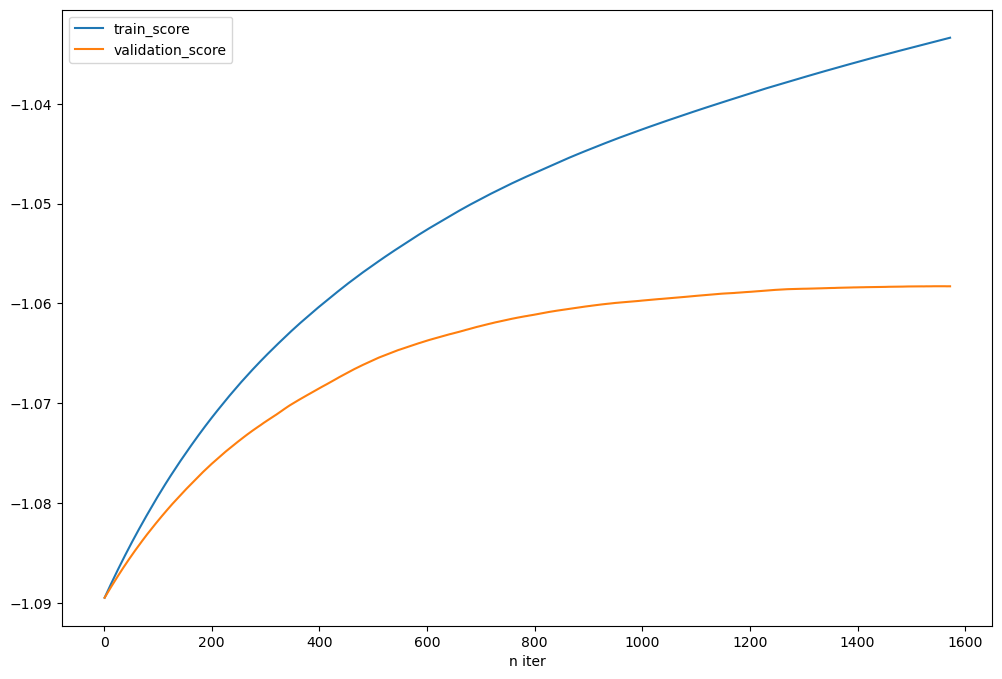

In [34]:
fig, ax = plt.subplots(figsize=(12, 8))

train_scores = hist.estimator.train_score_
validation_scores = hist.estimator.validation_score_
iter = range(1, len(train_scores) + 1)

ax.plot(iter, train_scores, label="train_score")
ax.plot(iter, validation_scores, label="validation_score")
ax.set_xlabel("n iter")
ax.legend();

In [35]:
df_train = df_train.with_columns(hist.predict(df_train[train_cols]))

In [36]:
df_test = df_test.with_columns(hist.predict(df_test[train_cols]))

In [37]:
print(
    classification_report(
        df_train[target], df_train["result_class_pred_hgbm"], zero_division=0
    )
)

              precision    recall  f1-score   support

          -1       0.47      0.65      0.55      5177
           0       0.62      0.01      0.01      3838
           1       0.47      0.64      0.54      5158

    accuracy                           0.47     14173
   macro avg       0.52      0.43      0.37     14173
weighted avg       0.51      0.47      0.40     14173



In [38]:
print(
    classification_report(
        df_test[target], df_test["result_class_pred_hgbm"], zero_division=0
    )
)

              precision    recall  f1-score   support

          -1       0.48      0.64      0.55      1298
           0       0.33      0.01      0.01       919
           1       0.49      0.65      0.56      1327

    accuracy                           0.48      3544
   macro avg       0.43      0.43      0.37      3544
weighted avg       0.44      0.48      0.41      3544



In [39]:
mean_ak_score(
    df_train[goals], df_train[["goals_team_1_pred_hgbm", "goals_team_2_pred_hgbm"]]
)

np.float64(1.0345022225358076)

In [40]:
mean_ak_score(
    df_test[goals], df_test[["goals_team_1_pred_hgbm", "goals_team_2_pred_hgbm"]]
)

np.float64(1.0434537246049662)

In [41]:
df_2425 = df.filter(pl.col("league_id") == 4741)
df_2425 = df_2425.with_columns(hist.predict(df_2425[train_cols]))

In [42]:
ak_score(
    df_2425[goals], df_2425[["goals_team_1_pred_hgbm", "goals_team_2_pred_hgbm"]]
).sum()

np.int64(115)

In [43]:
from lightgbm import LGBMClassifier

lgbm = GoalsMapper(
    LGBMClassifier(
        n_estimators=3000, learning_rate=0.001, objective="multiclass", num_leaves=8
    ),
    suffix="_lgbm",
)

lgbm.fit(df_train.select(train_cols), df_train.select(target), df_train[goals])

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000563 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3978
[LightGBM] [Info] Number of data points in the train set: 14173, number of used features: 48
[LightGBM] [Info] Start training from score -1.007113
[LightGBM] [Info] Start training from score -1.306387
[LightGBM] [Info] Start training from score -1.010790


/home/fabian/miniforge3/envs/AK-Tippspiel/lib/python3.11/site-packages/sklearn/preprocessing/_label.py:97: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/fabian/miniforge3/envs/AK-Tippspiel/lib/python3.11/site-packages/sklearn/preprocessing/_label.py:132: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


In [44]:
df_train = df_train.with_columns(lgbm.predict(df_train[train_cols]))

In [45]:
df_test = df_test.with_columns(lgbm.predict(df_test[train_cols]))

In [46]:
print(
    classification_report(
        df_train[target], df_train["result_class_pred_lgbm"], zero_division=0
    )
)

              precision    recall  f1-score   support

          -1       0.48      0.64      0.55      5177
           0       0.76      0.01      0.03      3838
           1       0.47      0.65      0.55      5158

    accuracy                           0.47     14173
   macro avg       0.57      0.44      0.37     14173
weighted avg       0.55      0.47      0.41     14173



In [47]:
print(
    classification_report(
        df_test[target], df_test["result_class_pred_lgbm"], zero_division=0
    )
)

              precision    recall  f1-score   support

          -1       0.47      0.64      0.54      1298
           0       0.40      0.01      0.02       919
           1       0.49      0.65      0.55      1327

    accuracy                           0.48      3544
   macro avg       0.45      0.43      0.37      3544
weighted avg       0.46      0.48      0.41      3544



In [48]:
mean_ak_score(
    df_train[goals], df_train[["goals_team_1_pred_lgbm", "goals_team_2_pred_lgbm"]]
)

np.float64(1.0425456854582658)

In [49]:
mean_ak_score(
    df_test[goals], df_test[["goals_team_1_pred_lgbm", "goals_team_2_pred_lgbm"]]
)

np.float64(1.0414785553047403)

In [50]:
df_2425 = df.filter(pl.col("league_id") == 4741)
df_2425 = df_2425.with_columns(lgbm.predict(df_2425[train_cols]))

In [51]:
ak_score(
    df_2425[goals], df_2425[["goals_team_1_pred_lgbm", "goals_team_2_pred_lgbm"]]
).sum()

np.int64(109)

In [52]:
importances = pl.DataFrame(
    {"feature": train_cols, "importance": lgbm.estimator.feature_importances_}
)
importances.sort("importance", descending=True).head(10)

feature,importance
str,i32
"""goals_scored_avg_1""",5196
"""goals_scored_avg_2""",5102
"""home_team""",4486
"""goals_diff_avg_2""",4110
"""rank_diff""",4056
"""goals_diff_avg_1""",4046
"""goals_conceded_avg_1""",2512
"""goals_diff_last_5_games_1""",2456
"""losses_avg_2""",2454


In [53]:
from sklearn.metrics import roc_auc_score

In [54]:
roc_auc_score(
    df_test["result_class"],
    lgbm.estimator.predict_proba(df_test[train_cols]),
    multi_class="ovr",
)

np.float64(0.6155980292371456)

## Save models

In [57]:
import joblib

In [59]:
joblib.dump((lgbm, train_cols), "../models/lgbm.pkl")

['../models/lgbm.pkl']